## Fuzzy Regression Discontinuity

**Question:** Does playing in a bowl-game help schools get more players drafted ? Does it help them get more first round draft picks? (all else equal)

**Findings:** It would seem that if anything it hurts the players and schools slightly (due to the negative coefficent in all specifications), but this is hard to say because the coefficent in question is statistically insignificant in all specificiations. Thus, it likely has no effect.

-----

Imports

In [56]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

#RD package
from rdrobust import rdrobust,rdplot

### Data Loading & Cleaning

Team-Season Data

In [2]:
post_season=pl.read_csv(r'/home/porter/Desktop/cfb-projects/cfb data/cfb_games_2005_2025.csv')

post_season=post_season.filter((pl.col('season_type')=='postseason'))
post_season=post_season.select(['season_type','game_id','season','neutral_site','attendance','home_id','home_team','home_conference','home_points','home_line_scores','away_team','away_conference','away_points','away_line_scores','home_classification','away_classification','home_pregame_elo','away_pregame_elo'])

post_season_home=post_season.with_columns(pl.col('home_team').alias('team'))
post_season_home=post_season_home.select(pl.exclude(['away_classification','away_pregame_elo'])).rename({'home_classification':'team_classification','home_pregame_elo':'team_pregame_elo'})
post_season_away=post_season.with_columns(pl.col('away_team').alias('team'))
post_season_away=post_season_away.select(pl.exclude(['home_classification','home_pregame_elo'])).rename({'away_classification':'team_classification','away_pregame_elo':'team_pregame_elo'})

                                    
team_season=pl.read_parquet(r'/home/porter/Desktop/cfb-projects/cfb data/merged_team_season_all.parquet')

#split it up because each row has two teams
team_season_bowl1=team_season.select(['season','team','team_season_id','record_classification']).join(post_season_home,on=['season','team'])

team_season_bowl2=team_season.select(['season','team','team_season_id','record_classification']).join(post_season_away,on=['season', 'team'])
#join it 
team_season_bowl=pl.concat([team_season_bowl1,team_season_bowl2],how='diagonal_relaxed')

#make a full dataset
team_season=team_season.join(team_season_bowl,on=['season','team'],how='left')

team_season

team_season_id,season,team,basic_conference,basic_first_downs,basic_first_downs_opponent,basic_fourth_down_conversions,basic_fourth_down_conversions_opponent,basic_fourth_downs,basic_fourth_downs_opponent,basic_fumbles_lost,basic_fumbles_lost_opponent,basic_fumbles_recovered,basic_fumbles_recovered_opponent,basic_games,basic_interception_t_ds,basic_interception_t_ds_opponent,basic_interception_yards,basic_interception_yards_opponent,basic_interceptions,basic_interceptions_opponent,basic_kick_return_t_ds,basic_kick_return_t_ds_opponent,basic_kick_return_yards,basic_kick_return_yards_opponent,basic_kick_returns,basic_kick_returns_opponent,basic_net_passing_yards,basic_net_passing_yards_opponent,basic_pass_attempts,basic_pass_attempts_opponent,basic_pass_completions,basic_pass_completions_opponent,basic_passes_intercepted,basic_passes_intercepted_opponent,basic_passing_t_ds,basic_passing_t_ds_opponent,…,ranking_afca_division_iii_coaches_poll_avg_rank,ranking_ap_top_25_avg_rank,ranking_bcs_standings_avg_rank,ranking_coaches_poll_avg_rank,ranking_fcs_coaches_poll_avg_rank,ranking_playoff_committee_rankings_avg_rank,ranking_afca_division_ii_coaches_poll_final_rank,ranking_afca_division_iii_coaches_poll_final_rank,ranking_ap_top_25_final_rank,ranking_bcs_standings_final_rank,ranking_coaches_poll_final_rank,ranking_fcs_coaches_poll_final_rank,ranking_playoff_committee_rankings_final_rank,ranking_afca_division_ii_coaches_poll_final_points,ranking_afca_division_iii_coaches_poll_final_points,ranking_ap_top_25_final_points,ranking_bcs_standings_final_points,ranking_coaches_poll_final_points,ranking_fcs_coaches_poll_final_points,ranking_playoff_committee_rankings_final_points,team_season_id_right,record_classification_right,season_type,game_id,neutral_site,attendance,home_id,home_team,home_conference,home_points,home_line_scores,away_team,away_conference,away_points,away_line_scores,team_classification,team_pregame_elo
str,i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,i64,bool,f64,i64,str,str,f64,str,str,str,f64,str,str,f64
"""2006_Air Force""",2006,"""Air Force""","""Mountain West""",241.0,230.0,12.0,8.0,22.0,14.0,10.0,11.0,11.0,10.0,12.0,0.0,1.0,67.0,20.0,4.0,9.0,null,null,null,null,null,null,1317.0,2669.0,146.0,303.0,84.0,202.0,9.0,4.0,12.0,20.0,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""2006_Akron""",2006,"""Akron""","""Mid-American""",206.0,215.0,15.0,15.0,27.0,29.0,9.0,15.0,15.0,9.0,12.0,0.0,2.0,68.0,174.0,11.0,7.0,null,null,null,null,null,null,2965.0,2323.0,384.0,336.0,202.0,186.0,7.0,10.0,18.0,13.0,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""2006_Alabama""",2006,"""Alabama""","""SEC""",247.0,196.0,7.0,10.0,13.0,17.0,13.0,12.0,12.0,13.0,13.0,3.0,2.0,266.0,199.0,10.0,16.0,null,null,null,null,null,null,2976.0,2350.0,393.0,331.0,224.0,184.0,16.0,10.0,17.0,15.0,…,null,null,null,23.75,null,null,null,null,null,null,22.0,null,null,null,null,null,null,314.0,null,null,"""2006_Alabama""","""fbs""","""postseason""",263620333,true,45054.0,333,"""Alabama""","""SEC""",31.0,"""[7, 7, 3, 14]""","""Oklahoma State""","""Big 12""",34.0,"""[7, 17, 0, 10]""","""fbs""",1665.0
"""2006_Alabama A&M""",2006,"""Alabama A&M""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""2006

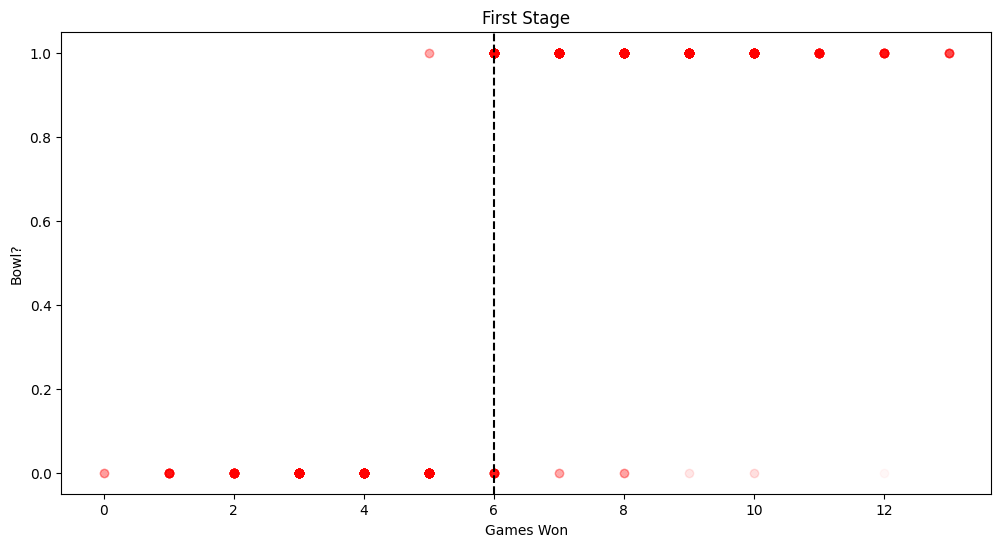

In [41]:
rd_graph=team_season.select(['season_type','record_regular_season_wins','season','team','record_classification'])

rd_graph=rd_graph.filter(pl.col('season')!=2020) #drop covid year
rd_graph=rd_graph.with_columns(
    pl.when(pl.col('season_type').is_not_null())
    .then(1)
    .otherwise(0)
    .alias('bowl')
) #make bowl indicator

rd_graph=rd_graph.filter(pl.col('record_regular_season_wins').is_not_null())

rd_graph=rd_graph.filter(pl.col('record_classification')=='fbs') #filter to only fbs


plt.figure(figsize=(12,6))
x=rd_graph['record_regular_season_wins'].to_pandas()
y=rd_graph['bowl'].to_pandas()

plt.scatter(x,y,c='red',alpha=.03)
plt.axvline(x=6,linestyle='--',c='black')
plt.title('First Stage')
plt.xlabel('Games Won')

plt.ylabel('Bowl?')
plt.show()


In [4]:
rd_graph

season_type,record_regular_season_wins,season,team,record_classification,bowl
str,f64,i64,str,str,i32
null,4.0,2006,"""Air Force""","""fbs""",0
null,5.0,2006,"""Akron""","""fbs""",0
"""postseason""",6.0,2006,"""Alabama""","""fbs""",1
null,6.0,2006,"""Arizona""","""fbs""",0
"""postseason""",7.0,2006,"""Arizona State""","""fbs""",1
…,…,…,…,…,…
null,4.0,2025,"""West Virginia""","""fbs""",0
"""postseason""",8.0,2025,"""Western Kentucky""","""fbs""",1
"""postseason""",9.0,2025,"""Western Michigan""","""fbs""",1


Draft Data

In [5]:
draft_data=pl.read_csv(r'/home/porter/Desktop/cfb-projects/cfb data/cfbd_nfl_draft_picks_2005_2025.csv')

draft_data=draft_data.with_columns((pl.col('year')-1).alias('season'))
draft_data=draft_data.with_columns((pl.col('college_team')).alias('team'))
draft_data

year,overall,round,pick,name,player_name_key,position,college_team,college_team_key,college_conference,cfbd_college_id,cfbd_college_athlete_id,nfl_team,nfl_team_id,nfl_athlete_id,height,weight,pre_draft_ranking,pre_draft_position_ranking,pre_draft_grade,is_first_round,is_top_5,is_top_10,is_top_32,draft_day,draft_capital_inverse,draft_capital_log_inverse,draft_capital_exp_decay,draft_pick_percentile_top,within_round_pick_percentile_top,board_surplus_overall,absolute_board_miss,hometown_info_city,hometown_info_state,hometown_info_country,hometown_info_latitude,hometown_info_longitude,hometown_info_county_fips,position_rank_available,season,team
i64,i64,i64,i64,str,str,str,str,str,str,i64,f64,str,i64,i64,f64,f64,f64,f64,f64,bool,bool,bool,bool,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,f64,f64,i64,bool,i64,str
2019,1,1,1,"""Kyler Murray""","""kyler murray""","""Quarterback""","""Oklahoma""","""oklahoma""","""Big 12""",201,3.917315e6,"""Arizona""",22,103832,70.0,207.0,9.0,1.0,90.0,true,true,true,true,1.0,1.0,-0.0,1.0,1.0,1.0,8.0,8.0,"""Allen""","""TX""","""USA""",33.103174,-96.67055,48085,true,2018,"""Oklahoma"""
2008,1,1,1,"""Jake Long""","""jake long""","""Offensive Tackle""","""Michigan""","""michigan""","""Big Ten""",130,2.130748e6,"""Miami""",15,12044,79.0,313.0,4.0,1.0,98.0,true,true,true,true,1.0,1.0,-0.0,1.0,1.0,1.0,3.0,3.0,null,null,null,null,null,null,true,2007,"""Michigan"""
2010,1,1,1,"""Sam Bradford""","""sam bradford""","""Quarterback""","""Oklahoma""","""oklahoma""","""Big 12""",201,188934.0,"""Los Angeles""",14,25545,76.0,236.0,3.0,1.0,97.0,true,true,true,true,1.0,1.0,-0.0,1.0,1.0,1.0,2.0,2.0,"""Oklahoma City""","""OK""","""USA""",35.472989,-97.517054,40109,true,2009,"""Oklahoma"""
2016,1,1,1,"""Jared Goff""","""jared goff""","""Quarterback""","""California""","""california""","""Pac-12""",25,547401.0,"""Los Angeles""",14,49986,76.0,215.0,11.0,2.0,91.0,true,true,true,true,1.0,1.0,-0.0,1.0,1.0,1.0,10.0,10.0,"""Novato""","""CA""","""USA""",38.106198,-122.568119,6041,true,2015,"""California"""
2007,1,1,1,"""JaMarcus Russell""","""jamarcus russell""","""Quarterback""","""LSU""","""lsu""","""SEC""",99,2.131833e6,"""Las Vegas""",13,11405,78.0,256.0,2.0,1.0,98.0,true,true,true,true,1.0,1.0,-0.0,1.0,1.0,1.0,1.0,1.0,null,null,null,null,null,null,true,2006,"""LSU"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2023,259,7,42,"""Desjuan Johnson""","""desjuan johnson""","""Defensive End""","""Toledo""","""toledo""","""Mid-American""",2649,4.362294e6,"""Los Angeles""",14,107082,null,null,null,null,null,false,false,false,false,3.0,0.003861,-5.556828,0.005742,0.0,0.0,null,null,"""Detroit""","""MI""","""USA""",42.331551,-83.04664,26163,false,2022,"""Toledo"""
2021,259,7,32,"""Grant Stuard""","""grant stuard""","""Outside Linebacker""","""Houston""","""houston""","""American Athletic""",248,4.240255e6,"""Tampa Bay""",27,105194,72.0,225.0,216.0,9.0,45.0,false,false,false,false,3.0,0.003861,-5.556828,0.005742,0.0,0.0,-43.0,43.0,"""Conroe""","""TX""","""USA""",30.311877,-95.456051,48339,true,2020,"""Houston"""
2022,260,7,39,"""Zander Horvath""","""zander horvath""","""Fullback""","""Purdue""","""purdue""","""Big Ten""",2509,4.260406e6,"""Los Angeles""",24,106272,75.0,230.0,null,null,null,false,false,false,false,3.0,0.003846,-5.560682,0.005628,0.007663,0.05,null,null,"""Mishawaka""","""IN""","""USA""",41.661993,-86.158616,18141,false,2021,"""Purdue"""


In [6]:
draft_summary=pl.read_parquet(r'/home/porter/Desktop/cfb-projects/cfb data/cfbd_school_draft_summary_2005_2025.parquet')
draft_summary=draft_summary.with_columns((pl.col('year')-1).alias('season'))
draft_summary=draft_summary.with_columns(pl.col('college_team').alias('team'))

draft_summary

year,college_team,college_conference,drafted_players,first_rounders,top_10_picks,top_32_picks,avg_overall_pick,best_overall_pick,total_draft_capital_exp,avg_draft_pick_percentile_top,season,team
i64,str,str,i64,i64,i64,i64,f64,i64,f64,f64,i64,str
2005,"""Oklahoma""","""Big 12""",11,2,0,2,92.090909,13,3.223244,0.641374,2004,"""Oklahoma"""
2005,"""Florida State""","""ACC""",9,2,0,2,100.111111,16,2.209578,0.609799,2004,"""Florida State"""
2005,"""Virginia""","""ACC""",7,1,0,1,135.142857,30,1.001306,0.471879,2004,"""Virginia"""
2005,"""Wisconsin""","""Big Ten""",7,1,0,1,138.714286,18,1.123942,0.457818,2004,"""Wisconsin"""
2005,"""Georgia""","""SEC""",6,2,0,2,55.0,14,2.655093,0.787402,2004,"""Georgia"""
…,…,…,…,…,…,…,…,…,…,…,…,…
2025,"""Washington State""","""Pac-12""",1,0,0,0,69.0,69,0.256661,0.734375,2024,"""Washington State"""
2025,"""West Virginia""","""Big 12""",1,0,0,0,89.0,89,0.172045,0.65625,2024,"""West Virginia"""
2025,"""Western Kentucky""","""Conference USA""",1,0,0,0,100.0,100,0.138069,0.613281,2024,"""Western Kentucky"""


In [7]:
team_season_draft_summary=team_season.join(draft_summary,on=['team','season'],how='left')

#make a conference ID
team_season_draft_summary=team_season_draft_summary.with_columns(
    pl.when(pl.col("basic_conference").is_not_null())
    .then(pl.col("basic_conference").cast(pl.Categorical).to_physical())
    .otherwise(None)
    .alias("conference_id")
)


#get rid of trash cols
team_season_draft_summary=team_season_draft_summary.select(pl.exclude([ 'team_season_id','basic_games','advanced_offense_drives',
 'advanced_offense_ppa',
 'advanced_offense_total_ppa',
 'advanced_offense_success_rate',
 'advanced_offense_explosiveness',
 'advanced_offense_power_success',
 'advanced_offense_stuff_rate',
 'advanced_offense_line_yards',
 'advanced_offense_line_yards_total',
 'advanced_offense_second_level_yards',
 'advanced_offense_second_level_yards_total',
 'advanced_offense_open_field_yards',
 'advanced_offense_open_field_yards_total',
 'advanced_offense_total_opportunies',
 'advanced_offense_points_per_opportunity',
 'advanced_offense_field_position_average_start',
 'advanced_offense_field_position_average_predicted_points',
 'advanced_offense_havoc_total',
 'advanced_offense_havoc_front_seven',
 'advanced_offense_havoc_db',
 'advanced_offense_standard_downs_rate',
 'advanced_offense_standard_downs_ppa',
 'advanced_offense_standard_downs_success_rate',
 'advanced_offense_standard_downs_explosiveness',
 'advanced_offense_passing_downs_rate',
 'advanced_offense_passing_downs_ppa',
 'advanced_offense_passing_downs_success_rate',
 'advanced_offense_passing_downs_explosiveness',
 'advanced_offense_rushing_plays_rate',
 'advanced_offense_rushing_plays_ppa',
 'advanced_offense_rushing_plays_total_ppa',
 'advanced_offense_rushing_plays_success_rate',
 'advanced_offense_rushing_plays_explosiveness',
 'advanced_offense_passing_plays_rate',
 'advanced_offense_passing_plays_ppa',
 'advanced_offense_passing_plays_total_ppa',
 'advanced_offense_passing_plays_success_rate',
 'advanced_offense_passing_plays_explosiveness',
 'advanced_defense_drives',
 'advanced_defense_ppa',
 'advanced_defense_total_ppa',
 'advanced_defense_success_rate',
 'advanced_defense_explosiveness',
 'advanced_defense_power_success',
 'advanced_defense_stuff_rate',
 'advanced_defense_line_yards',
 'advanced_defense_line_yards_total',
 'advanced_defense_second_level_yards',
 'advanced_defense_second_level_yards_total',
 'advanced_defense_open_field_yards',
 'advanced_defense_open_field_yards_total',
 'advanced_defense_total_opportunies',
 'advanced_defense_points_per_opportunity',
 'advanced_defense_field_position_average_start',
 'advanced_defense_field_position_average_predicted_points',
 'advanced_defense_havoc_total',
 'advanced_defense_havoc_front_seven',
 'advanced_defense_havoc_db',
 'advanced_defense_standard_downs_rate',
 'advanced_defense_standard_downs_ppa',
 'advanced_defense_standard_downs_success_rate',
 'advanced_defense_standard_downs_explosiveness',
 'advanced_defense_passing_downs_rate',
 'advanced_defense_passing_downs_ppa',
 'advanced_defense_passing_downs_total_ppa',
 'advanced_defense_passing_downs_success_rate',
 'advanced_defense_passing_downs_explosiveness',
 'advanced_defense_rushing_plays_rate',
 'advanced_defense_rushing_plays_ppa',
 'advanced_defense_rushing_plays_total_ppa',
 'advanced_defense_rushing_plays_success_rate',
 'advanced_defense_rushing_plays_explosiveness',
 'advanced_defense_passing_plays_rate',
 'advanced_defense_passing_plays_ppa',
 'advanced_defense_passing_plays_total_ppa',
 'advanced_defense_passing_plays_success_rate',
 'advanced_defense_passing_plays_explosiveness',
 'advanced_pull_year',
 'ppa_conference',
 'ppa_offense_overall',
 'ppa_offense_passing',
 'ppa_offense_rushing',
 'ppa_offense_first_down',
 'ppa_offense_second_down',
 'ppa_offense_third_down',
 'ppa_offense_cumulative_total',
 'ppa_offense_cumulative_passing',
 'ppa_offense_cumulative_rushing',
 'ppa_defense_overall',
 'ppa_defense_passing',
 'ppa_defense_rushing',
 'ppa_defense_first_down',
 'ppa_defense_second_down',
 'ppa_defense_third_down',
 'ppa_defense_cumulative_total',
 'ppa_defense_cumulative_passing',
 'ppa_defense_cumulative_rushing',
 'ppa_pull_year',
 'wepa_team_id',
 'wepa_conference',
 'wepa_explosiveness',
 'wepa_explosiveness_allowed',
 'wepa_epa_total',
 'wepa_epa_passing',
 'wepa_epa_rushing',
 'wepa_epa_allowed_total',
 'wepa_epa_allowed_passing',
 'wepa_epa_allowed_rushing',
 'wepa_success_rate_total',
 'wepa_success_rate_standard_downs',
 'wepa_success_rate_passing_downs',
 'wepa_success_rate_allowed_total',
 'wepa_success_rate_allowed_standard_downs',
 'wepa_success_rate_allowed_passing_downs',
 'wepa_rushing_line_yards',
 'wepa_rushing_second_level_yards',
 'wepa_rushing_open_field_yards',
 'wepa_rushing_highlight_yards',
 'wepa_rushing_allowed_line_yards',
 'wepa_rushing_allowed_second_level_yards',
 'wepa_rushing_allowed_open_field_yards',
 'wepa_rushing_allowed_highlight_yards',
 'wepa_pull_year',
'record_team_id',
'record_conference',
 'record_total_losses',
 'record_total_ties',
 'record_conference_games_games',
 'record_conference_games_ties',
 'record_home_games_games',
 'record_home_games_ties',
 'record_away_games_games',
'record_away_games_ties',
 'record_neutral_site_games_games',
 'record_neutral_site_games_wins',
 'record_neutral_site_games_losses',
 'record_neutral_site_games_ties',
 'record_regular_season_losses',
 'record_regular_season_ties',
 'record_postseason_games',
 'record_postseason_wins',
 'record_postseason_losses',
 'record_postseason_ties',
 'record_pull_year',

 'talent_pull_year',
 'returning_conference',
 'returning_total_ppa',
 'returning_total_passing_ppa',
 'returning_total_receiving_ppa',
 'returning_total_rushing_ppa',
 'returning_percent_ppa',
 'returning_percent_passing_ppa',
 'returning_percent_receiving_ppa',
 'returning_percent_rushing_ppa',
 'returning_usage',
 'returning_passing_usage',
 'returning_receiving_usage',
 'returning_rushing_usage',
 'returning_pull_year',
 'recruiting_rank',
'recruiting_pull_year',
 'recruit_group_all_positions_average_rating',
 'recruit_group_defensive_back_average_rating',
 'recruit_group_defensive_line_average_rating',
 'recruit_group_linebacker_average_rating',
 'recruit_group_offensive_line_average_rating',
 'recruit_group_quarterback_average_rating',
 'recruit_group_receiver_average_rating',
 'recruit_group_running_back_average_rating',
 'recruit_group_special_teams_average_rating',
 'recruit_group_all_positions_total_rating',
 'recruit_group_defensive_back_total_rating',
 'recruit_group_defensive_line_total_rating',
 'recruit_group_linebacker_total_rating',
 'recruit_group_offensive_line_total_rating',
 'recruit_group_quarterback_total_rating',
 'recruit_group_receiver_total_rating',
 'recruit_group_running_back_total_rating',
 'recruit_group_special_teams_total_rating',
 'recruit_group_all_positions_commits',
 'recruit_group_defensive_back_commits',
 'recruit_group_defensive_line_commits',
 'recruit_group_linebacker_commits',
 'recruit_group_offensive_line_commits',
 'recruit_group_quarterback_commits',
 'recruit_group_receiver_commits',
 'recruit_group_running_back_commits',
 'recruit_group_special_teams_commits',
 'recruit_group_all_positions_average_stars',
 'recruit_group_defensive_back_average_stars',
 'recruit_group_defensive_line_average_stars',
 'recruit_group_linebacker_average_stars',
 'recruit_group_offensive_line_average_stars',
 'recruit_group_quarterback_average_stars',
 'recruit_group_receiver_average_stars',
 'recruit_group_running_back_average_stars',
 'recruit_group_special_teams_average_stars',
'talent_talent',
 'elo_pull_year',
 'sp_conference',
'elo_conference',
'sp_rating',
 'sp_ranking',
 'sp_second_order_wins',
 'sp_sos',
 'sp_offense_ranking',
 'sp_offense_rating',
 'sp_offense_success',
 'sp_offense_explosiveness',
 'sp_offense_rushing',
 'sp_offense_passing',
 'sp_offense_standard_downs',
 'sp_offense_passing_downs',
 'sp_offense_run_rate',
 'sp_offense_pace',
 'sp_defense_ranking',
 'sp_defense_rating',
 'sp_defense_success',
 'sp_defense_explosiveness',
 'sp_defense_rushing',
 'sp_defense_passing',
 'sp_defense_standard_downs',
 'sp_defense_passing_downs',
 'sp_defense_havoc_total',
 'sp_defense_havoc_front_seven',
 'sp_defense_havoc_db',
 'sp_special_teams_rating',
 'sp_pull_year',
 'fpi_conference',
 'fpi_fpi',
 'fpi_resume_ranks_strength_of_record',
 'fpi_resume_ranks_fpi',
 'fpi_resume_ranks_average_win_probability',
 'fpi_resume_ranks_strength_of_schedule',
 'fpi_resume_ranks_remaining_strength_of_schedule',
 'fpi_resume_ranks_game_control',
 'fpi_efficiencies_overall',
 'fpi_efficiencies_offense',
 'fpi_efficiencies_defense',
 'fpi_efficiencies_special_teams',
 'fpi_pull_year',
 'srs_conference',
 'srs_division',
 'srs_ranking',
 'srs_rating',
 'srs_pull_year',
 'ranking_afca_division_ii_coaches_poll_weeks_ranked',
 'ranking_afca_division_iii_coaches_poll_weeks_ranked',
 'ranking_ap_top_25_weeks_ranked',
 'ranking_bcs_standings_weeks_ranked',
 'ranking_coaches_poll_weeks_ranked',
 'ranking_fcs_coaches_poll_weeks_ranked',
 'ranking_playoff_committee_rankings_weeks_ranked',
 'ranking_afca_division_ii_coaches_poll_best_rank',
 'ranking_afca_division_iii_coaches_poll_best_rank',
 'ranking_ap_top_25_best_rank',
 'ranking_bcs_standings_best_rank',
 'ranking_coaches_poll_best_rank',
 'ranking_fcs_coaches_poll_best_rank',
 'ranking_playoff_committee_rankings_best_rank',
 'ranking_afca_division_ii_coaches_poll_worst_rank',
 'ranking_afca_division_iii_coaches_poll_worst_rank',
 'ranking_ap_top_25_worst_rank',
 'ranking_bcs_standings_worst_rank',
 'ranking_coaches_poll_worst_rank',
 'ranking_fcs_coaches_poll_worst_rank',
 'ranking_playoff_committee_rankings_worst_rank',
 'ranking_afca_division_ii_coaches_poll_avg_rank',
 'ranking_afca_division_iii_coaches_poll_avg_rank',
 'ranking_ap_top_25_avg_rank',
 'ranking_bcs_standings_avg_rank',
 'ranking_coaches_poll_avg_rank',
 'ranking_fcs_coaches_poll_avg_rank',
 'ranking_playoff_committee_rankings_avg_rank',
 'ranking_afca_division_ii_coaches_poll_final_rank',
 'ranking_afca_division_iii_coaches_poll_final_rank',
 'ranking_ap_top_25_final_rank',
 'ranking_bcs_standings_final_rank',
 'ranking_coaches_poll_final_rank',
 'ranking_fcs_coaches_poll_final_rank',
 'ranking_playoff_committee_rankings_final_rank',
 'ranking_afca_division_ii_coaches_poll_final_points',
 'ranking_afca_division_iii_coaches_poll_final_points',
 'ranking_ap_top_25_final_points',
 'ranking_bcs_standings_final_points',
 'ranking_coaches_poll_final_points',
 'ranking_fcs_coaches_poll_final_points',
 'ranking_playoff_committee_rankings_final_points',
 'team_season_id_right',

]))


In [8]:
#make a pre-postseason elo
team_season_draft_summary=team_season_draft_summary.with_columns(
    pl.when((pl.col('season_type').is_null()))
    .then('elo_elo')
    .otherwise('team_pregame_elo')
    .alias('team_pregame_elo')
)

Simple Data (few controls, but quality)

In [9]:
team_season_draft_summary=team_season_draft_summary.select(pl.exclude('basic_first_downs',
 'basic_first_downs_opponent',
 'basic_fourth_down_conversions',
 'basic_fourth_down_conversions_opponent',
 'basic_fourth_downs',
 'basic_fourth_downs_opponent',
 'basic_fumbles_lost',
 'basic_fumbles_lost_opponent',
 'basic_fumbles_recovered',
 'basic_fumbles_recovered_opponent',
 'basic_interception_t_ds',
 'basic_interception_t_ds_opponent',
 'basic_interception_yards',
 'basic_interception_yards_opponent',
 'basic_interceptions',
 'basic_interceptions_opponent',
 'basic_kick_return_t_ds',
 'basic_kick_return_t_ds_opponent',
 'basic_kick_return_yards',
 'basic_kick_return_yards_opponent',
 'basic_kick_returns',
 'basic_kick_returns_opponent',
 'basic_net_passing_yards',
 'basic_net_passing_yards_opponent',
 'basic_pass_attempts',
 'basic_pass_attempts_opponent',
 'basic_pass_completions',
 'basic_pass_completions_opponent',
 'basic_passes_intercepted',
 'basic_passes_intercepted_opponent',
 'basic_passing_t_ds',
 'basic_passing_t_ds_opponent',
 'basic_penalties',
 'basic_penalties_opponent',
 'basic_penalty_yards',
 'basic_penalty_yards_opponent',
 'basic_possession_time',
 'basic_possession_time_opponent',
 'basic_punt_return_t_ds',
 'basic_punt_return_t_ds_opponent',
 'basic_punt_return_yards',
 'basic_punt_return_yards_opponent',
 'basic_punt_returns',
 'basic_punt_returns_opponent',
 'basic_rushing_attempts',
 'basic_rushing_attempts_opponent',
 'basic_rushing_t_ds',
 'basic_rushing_t_ds_opponent',
 'basic_rushing_yards',
 'basic_rushing_yards_opponent',
 'basic_sacks',
 'basic_sacks_opponent',
 'basic_tackles_for_loss',
 'basic_tackles_for_loss_opponent',
 'basic_third_down_conversions',
 'basic_third_down_conversions_opponent',
 'basic_third_downs',
 'basic_third_downs_opponent',
 'basic_total_yards',
 'basic_total_yards_opponent',
 'basic_turnovers',
 'basic_turnovers_opponent',
 'advanced_conference',
 'advanced_offense_plays',
 'advanced_defense_plays',
 'record_expected_wins',
 'record_total_wins',
 
 
 
 ))

#enum division and enum fbs/fcs
team_season_draft_summary=team_season_draft_summary.with_columns(
    pl.col('record_classification').cast(pl.Categorical).to_physical().alias('class_id')
)

team_season_draft_summary = team_season_draft_summary.with_columns(
    (
        pl.col('basic_conference').cast(pl.Utf8) +
        pl.col('record_division').cast(pl.Utf8)
    ).alias('conf_division')
)

#make it null if there are no divisions in the conf
team_season_draft_summary=team_season_draft_summary.with_columns(
    pl.when(pl.col('conf_division')==pl.col('basic_conference'))
    .then(None)
    .otherwise(pl.col('conf_division'))
    .alias('conf_division')
)
#make a division id
team_season_draft_summary=team_season_draft_summary.with_columns(
    pl.col('conf_division').cast(pl.Categorical()).to_physical().alias('division_id')
)

#make a bowl inidicator (itll also pick up fcs playoffs)
team_season_draft_summary=team_season_draft_summary.with_columns(
    pl.when(pl.col('season_type')=='postseason')
    .then(pl.lit(1))
    .otherwise(pl.lit(0))
    .alias('bowl')
)

#make a team id
team_season_draft_summary=team_season_draft_summary.with_columns(
    pl.col('team').cast(pl.Categorical()).to_physical().alias('team_id')
)

team_season_draft_summary=team_season_draft_summary.filter(pl.col('class_id').is_not_null())


In [10]:
#get only numeric cols
team_season_draft_summary=team_season_draft_summary.select(pl.exclude(['team','basic_conference','record_classification','record_division','record_total_games','record_classification_right','season_type','game_id',	'neutral_site',	'attendance'	,'home_id'	,'home_team'	,'home_conference'	,'home_points'	,'home_line_scores'	,'away_team'	,'away_conference'	,'away_points'	,'away_line_scores'	,'team_classification','year','college_team','college_conference','conf_division','elo_elo']))


### RD

In [14]:
rd_data=team_season_draft_summary.filter(pl.col('class_id')==0)
rd_data=rd_data.with_columns(
    pl.when(pl.col('drafted_players').is_null())
    .then(0)
    .otherwise(pl.col('drafted_players'))
    .alias('drafted_players')
)

rd_data=rd_data.with_columns(
    pl.when(pl.col('first_rounders').is_null())
    .then(0)
    .otherwise(pl.col('first_rounders'))
    .alias('first_rounders')
)

rd_data=rd_data.with_columns(
    (pl.col('record_regular_season_wins')-pl.col('record_conference_games_wins')).alias('ooc_wins')
)

rd_data=rd_data.with_columns((pl.col('record_regular_season_wins')-pl.lit(6)).alias('running_var'))

In [49]:
rd_data

season,record_conference_games_wins,record_conference_games_losses,record_home_games_wins,record_home_games_losses,record_away_games_wins,record_away_games_losses,record_regular_season_games,record_regular_season_wins,recruiting_points,team_pregame_elo,drafted_players,first_rounders,top_10_picks,top_32_picks,avg_overall_pick,best_overall_pick,total_draft_capital_exp,avg_draft_pick_percentile_top,conference_id,class_id,division_id,bowl,team_id,ooc_wins,running_var
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,f64,i64,f64,f64,u32,u32,u32,i32,u32,f64,f64
2006,3.0,5.0,2.0,4.0,2.0,4.0,12.0,4.0,45.95,1479.0,0,0,null,null,null,null,null,null,0,0,null,0,0,1.0,-2.0
2006,3.0,5.0,4.0,1.0,1.0,6.0,12.0,5.0,102.97,1323.0,1,0,0,0,88.0,88,0.17552,0.65748,1,0,0,0,1,2.0,-1.0
2006,2.0,6.0,6.0,2.0,0.0,4.0,12.0,6.0,233.66,1665.0,3,0,0,0,212.666667,137,0.079541,0.166667,2,0,1,1,2,4.0,0.0
2006,5.0,5.0,3.0,4.0,3.0,2.0,12.0,6.0,213.58,1552.0,4,0,0,0,171.5,50,0.425353,0.32874,3,0,null,0,7,1.0,0.0
2006,4.0,5.0,4.0,2.0,3.0,3.0,12.0,7.0,188.18,1628.0,2,0,0,0,145.0,38,0.483718,0.433071,3,0,null,1,8,3.0,1.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2025,2.0,7.0,3.0,3.0,1.0,5.0,12.0,4.0,205.16,1291.0,0,0,null,null,null,null,null,null,6,0,null,0,230,2.0,-2.0
2025,6.0,2.0,5.0,1.0,3.0,3.0,12.0,8.0,152.76,1401.0,0,0,null,null,null,null,null,null,10,0,null,1,233,2.0,2.0
2025,7.0,1.0,5.0,1.0,3.0,3.0,13.0,9.0,141.86,1442.0,0,0,null,null,null,null,null,null,1,0,null,1,234,2.0,3.0


#### RD with School Draft Picks

In [43]:
#outcome
y=rd_data['drafted_players'].to_pandas()

#running var
x=rd_data['running_var'].to_pandas()

#treatment var
z=rd_data['bowl'].to_pandas()

#covariates
covariates=rd_data.select(['record_conference_games_wins','recruiting_points','team_pregame_elo','conference_id','team_id','season']).to_pandas()


results=rdrobust(y=y,x=x,fuzzy=z,covs=covariates,p=1,cluster=rd_data['team_id'].to_pandas(),vce='cr3')
print(results)


Mass points detected in the running variable.
Call: rdrobust

Covariate-adjusted Fuzzy RD estimates using local polynomial regression. Std. errors are clustered (137 clusters).

Number of Observations:                  2561
Polynomial Order Est. (p):                  1
Polynomial Order Bias (q):                  2
Kernel:                            Triangular
Bandwidth Selection:                    mserd
Var-Cov Estimator:                        CR3

                                Left      Right
------------------------------------------------
Number of Observations           987       1574
Number of Unique Obs.              6          8
Number of Effective Obs.         513        946
Bandwidth Estimation           2.318      2.318
Bandwidth Bias                 4.033      4.033
rho (h/b)                      0.575      0.575
Number of Clusters               128        136

Method             Coef.     S.E.   z-stat    P>|z|       95% CI      
----------------------------------------

Mass points detected in the running variable.


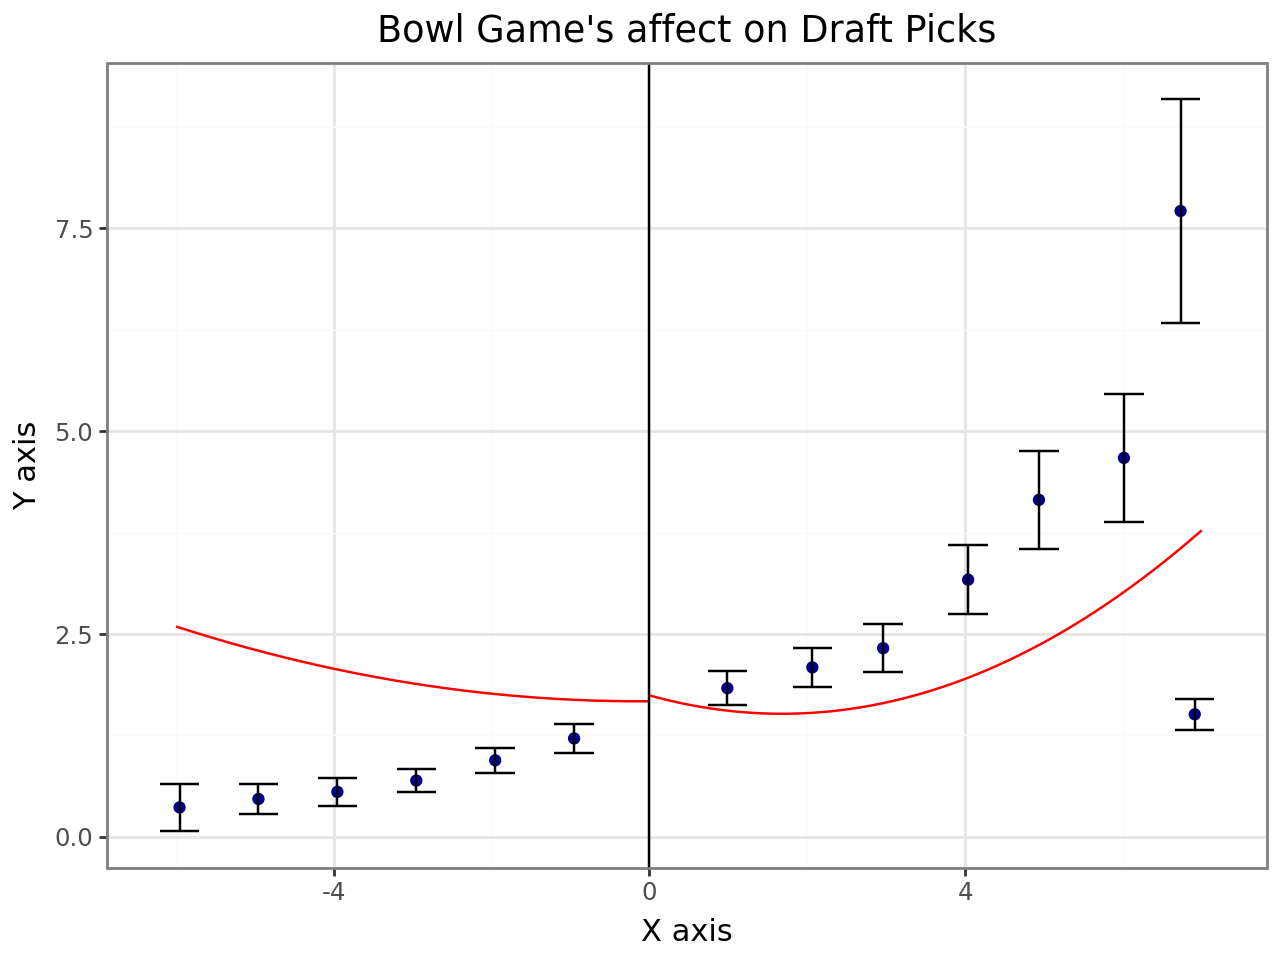

/home/porter/Desktop/cfb-projects/.venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
/home/porter/Desktop/cfb-projects/.venv/lib/python3.14/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide


Call: rdplot
Number of Observations:                  2561
Kernel:                               Uniform
Polynomial Order Est. (p):                  2

                                Left      Right
------------------------------------------------
Number of Observations           987       1574
Number of Effective Obs          987       1574
Bandwidth poly. fit (h)          6.0        7.0
Number of bins scale               1          1
Bins Selected                     66         39
Average Bin Length             0.142        nan
Median Bin Length              0.179        nan
IMSE-optimal bins                7.0       10.0
Mimicking Variance bins         66.0       39.0

Relative to IMSE-optimal:
Implied scale                  9.429        3.9
WIMSE variance weight          0.001      0.017
WIMSE bias weight              0.999      0.983

In [45]:
rdplot(y,x,covs=covariates,ci=95,title='Bowl Game\'s affect on Draft Picks',p=2)

#### RD with First Round Draft Picks

In [46]:
#outcome
y=rd_data['first_rounders'].to_pandas()

#running var
x=rd_data['running_var'].to_pandas()

#treatment var
z=rd_data['bowl'].to_pandas()

#covariates
covariates=rd_data.select(['record_conference_games_wins','recruiting_points','team_pregame_elo','conference_id','team_id','season']).to_pandas()


results=rdrobust(y=y,x=x,fuzzy=z,covs=covariates,p=1,cluster=rd_data['team_id'].to_pandas(),vce='cr3')
print(results)


Mass points detected in the running variable.
Call: rdrobust

Covariate-adjusted Fuzzy RD estimates using local polynomial regression. Std. errors are clustered (136 clusters).

Number of Observations:                  2561
Polynomial Order Est. (p):                  1
Polynomial Order Bias (q):                  2
Kernel:                            Triangular
Bandwidth Selection:                    mserd
Var-Cov Estimator:                        CR3

                                Left      Right
------------------------------------------------
Number of Observations           987       1574
Number of Unique Obs.              6          8
Number of Effective Obs.         513        946
Bandwidth Estimation            2.57       2.57
Bandwidth Bias                 3.939      3.939
rho (h/b)                      0.652      0.652
Number of Clusters               127        135

Method             Coef.     S.E.   z-stat    P>|z|       95% CI      
----------------------------------------

Mass points detected in the running variable.


/home/porter/Desktop/cfb-projects/.venv/lib/python3.14/site-packages/rdrobust/rdplot.py:577: RuntimeWarning: divide by zero encountered in divide
/home/porter/Desktop/cfb-projects/.venv/lib/python3.14/site-packages/rdrobust/rdplot.py:591: RuntimeWarning: divide by zero encountered in scalar divide


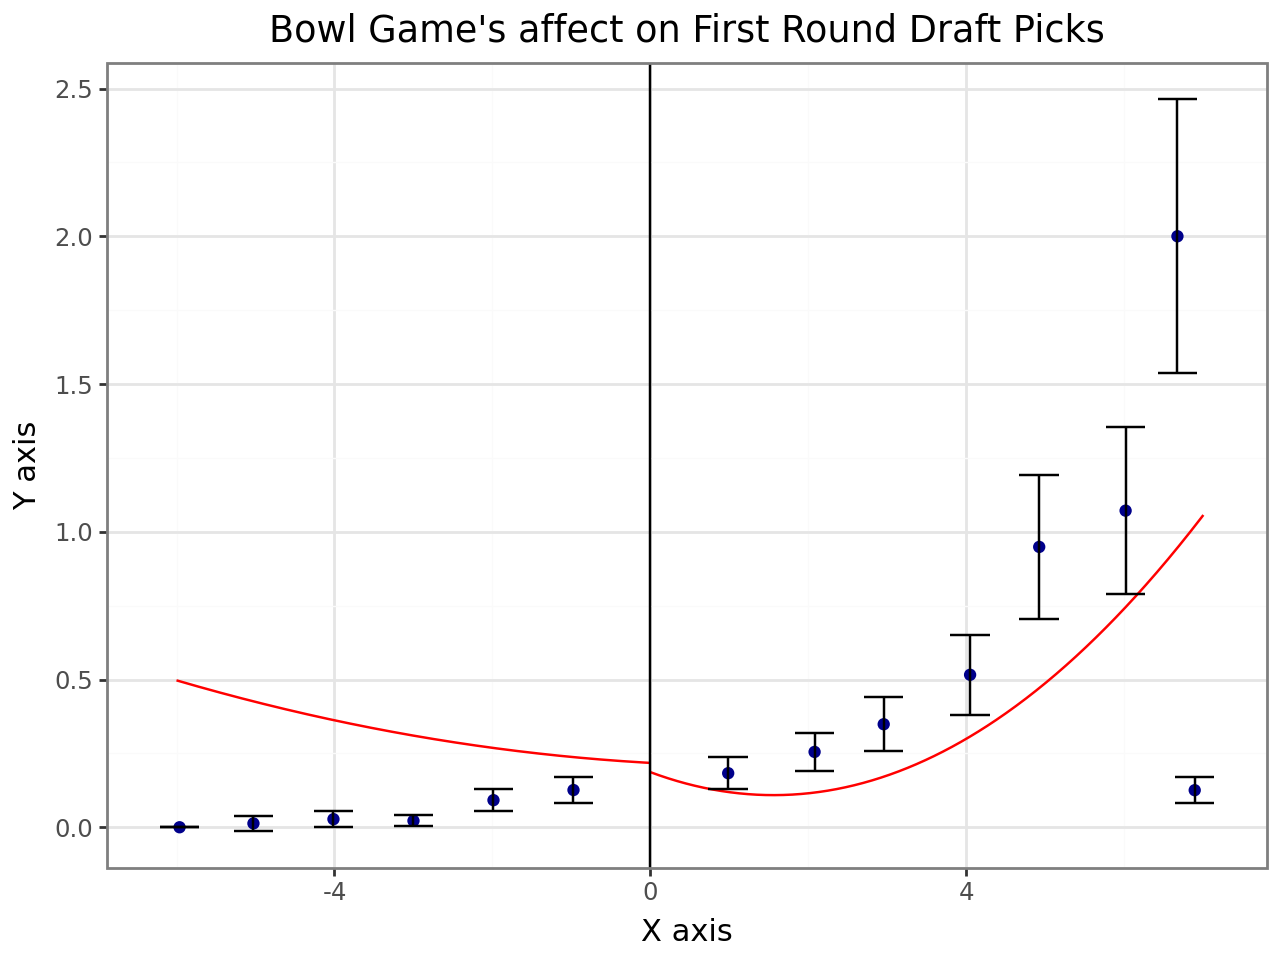

/home/porter/Desktop/cfb-projects/.venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
/home/porter/Desktop/cfb-projects/.venv/lib/python3.14/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide


Call: rdplot
Number of Observations:                  2561
Kernel:                               Uniform
Polynomial Order Est. (p):                  2

                                Left      Right
------------------------------------------------
Number of Observations           987       1574
Number of Effective Obs          987       1574
Bandwidth poly. fit (h)          6.0        7.0
Number of bins scale               1          1
Bins Selected                     77         32
Average Bin Length             0.158        nan
Median Bin Length              0.219        nan
IMSE-optimal bins                7.0        9.0
Mimicking Variance bins         77.0       32.0

Relative to IMSE-optimal:
Implied scale                   11.0      3.556
WIMSE variance weight          0.001      0.022
WIMSE bias weight              0.999      0.978

In [48]:
rdplot(y,x,covs=covariates,ci=95,title='Bowl Game\'s affect on First Round Draft Picks',p=2)

#### Sub-setting to data where opt-outs are much less common (2005-2015)

In [ ]:
rd_data_2015=rd_data.filter(pl.col('season')<=2015)
rd_data_2015

##### Number of Draft Picks

In [52]:
#outcome
y=rd_data_2015['drafted_players'].to_pandas()

#running var
x=rd_data_2015['running_var'].to_pandas()

#treatment var
z=rd_data_2015['bowl'].to_pandas()

#covariates
covariates=rd_data_2015.select(['record_conference_games_wins','recruiting_points','team_pregame_elo','conference_id','team_id','season']).to_pandas()


results=rdrobust(y=y,x=x,fuzzy=z,covs=covariates,p=1,cluster=rd_data_2015['team_id'].to_pandas(),vce='cr3')
print(results)


Mass points detected in the running variable.
Call: rdrobust

Covariate-adjusted Fuzzy RD estimates using local polynomial regression. Std. errors are clustered (129 clusters).

Number of Observations:                  1217
Polynomial Order Est. (p):                  1
Polynomial Order Bias (q):                  2
Kernel:                            Triangular
Bandwidth Selection:                    mserd
Var-Cov Estimator:                        CR3

                                Left      Right
------------------------------------------------
Number of Observations           456        761
Number of Unique Obs.              6          8
Number of Effective Obs.         232        456
Bandwidth Estimation            2.36       2.36
Bandwidth Bias                 4.219      4.219
rho (h/b)                      0.559      0.559
Number of Clusters               111        126

Method             Coef.     S.E.   z-stat    P>|z|       95% CI      
----------------------------------------

Mass points detected in the running variable.


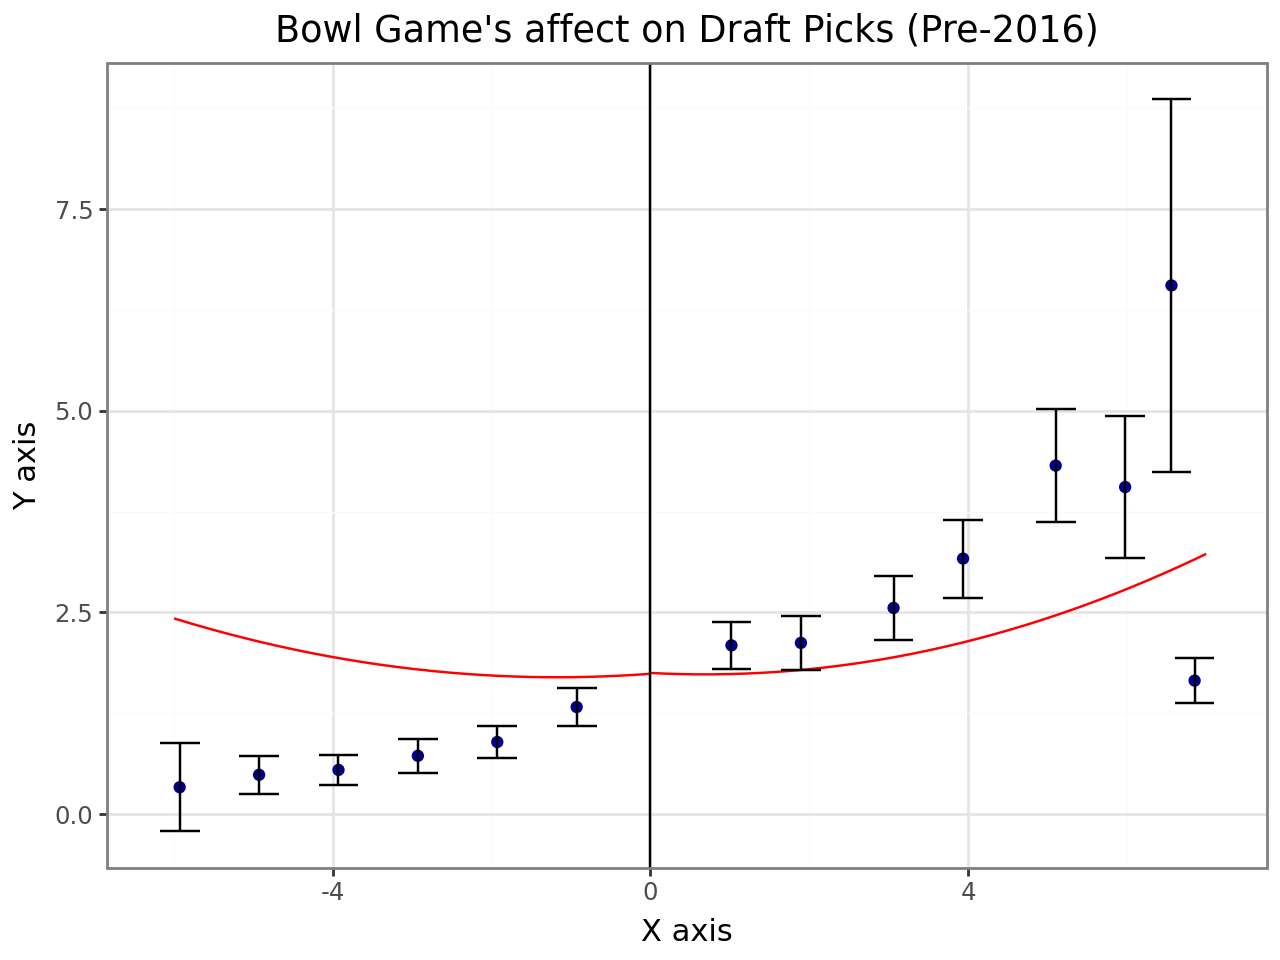

/home/porter/Desktop/cfb-projects/.venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
/home/porter/Desktop/cfb-projects/.venv/lib/python3.14/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide


Call: rdplot
Number of Observations:                  1217
Kernel:                               Uniform
Polynomial Order Est. (p):                  2

                                Left      Right
------------------------------------------------
Number of Observations           456        761
Number of Effective Obs          456        761
Bandwidth poly. fit (h)          6.0        7.0
Number of bins scale               1          1
Bins Selected                     42         24
Average Bin Length             0.228        nan
Median Bin Length              0.292        nan
IMSE-optimal bins                8.0        7.0
Mimicking Variance bins         42.0       24.0

Relative to IMSE-optimal:
Implied scale                   5.25      3.429
WIMSE variance weight          0.007      0.024
WIMSE bias weight              0.993      0.976

In [53]:
rdplot(y,x,covs=covariates,ci=95,title='Bowl Game\'s affect on Draft Picks (Pre-2016)',p=2)

##### First Round Draft Picks

In [54]:
#outcome
y=rd_data_2015['first_rounders'].to_pandas()

#running var
x=rd_data_2015['running_var'].to_pandas()

#treatment var
z=rd_data_2015['bowl'].to_pandas()

#covariates
covariates=rd_data_2015.select(['record_conference_games_wins','recruiting_points','team_pregame_elo','conference_id','team_id','season']).to_pandas()


results=rdrobust(y=y,x=x,fuzzy=z,covs=covariates,p=1,cluster=rd_data_2015['team_id'].to_pandas(),vce='cr3')
print(results)


Mass points detected in the running variable.
Call: rdrobust

Covariate-adjusted Fuzzy RD estimates using local polynomial regression. Std. errors are clustered (129 clusters).

Number of Observations:                  1217
Polynomial Order Est. (p):                  1
Polynomial Order Bias (q):                  2
Kernel:                            Triangular
Bandwidth Selection:                    mserd
Var-Cov Estimator:                        CR3

                                Left      Right
------------------------------------------------
Number of Observations           456        761
Number of Unique Obs.              6          8
Number of Effective Obs.         232        456
Bandwidth Estimation           2.533      2.533
Bandwidth Bias                 4.444      4.444
rho (h/b)                       0.57       0.57
Number of Clusters               111        126

Method             Coef.     S.E.   z-stat    P>|z|       95% CI      
----------------------------------------

Mass points detected in the running variable.


/home/porter/Desktop/cfb-projects/.venv/lib/python3.14/site-packages/rdrobust/rdplot.py:577: RuntimeWarning: divide by zero encountered in divide
/home/porter/Desktop/cfb-projects/.venv/lib/python3.14/site-packages/rdrobust/rdplot.py:591: RuntimeWarning: divide by zero encountered in scalar divide


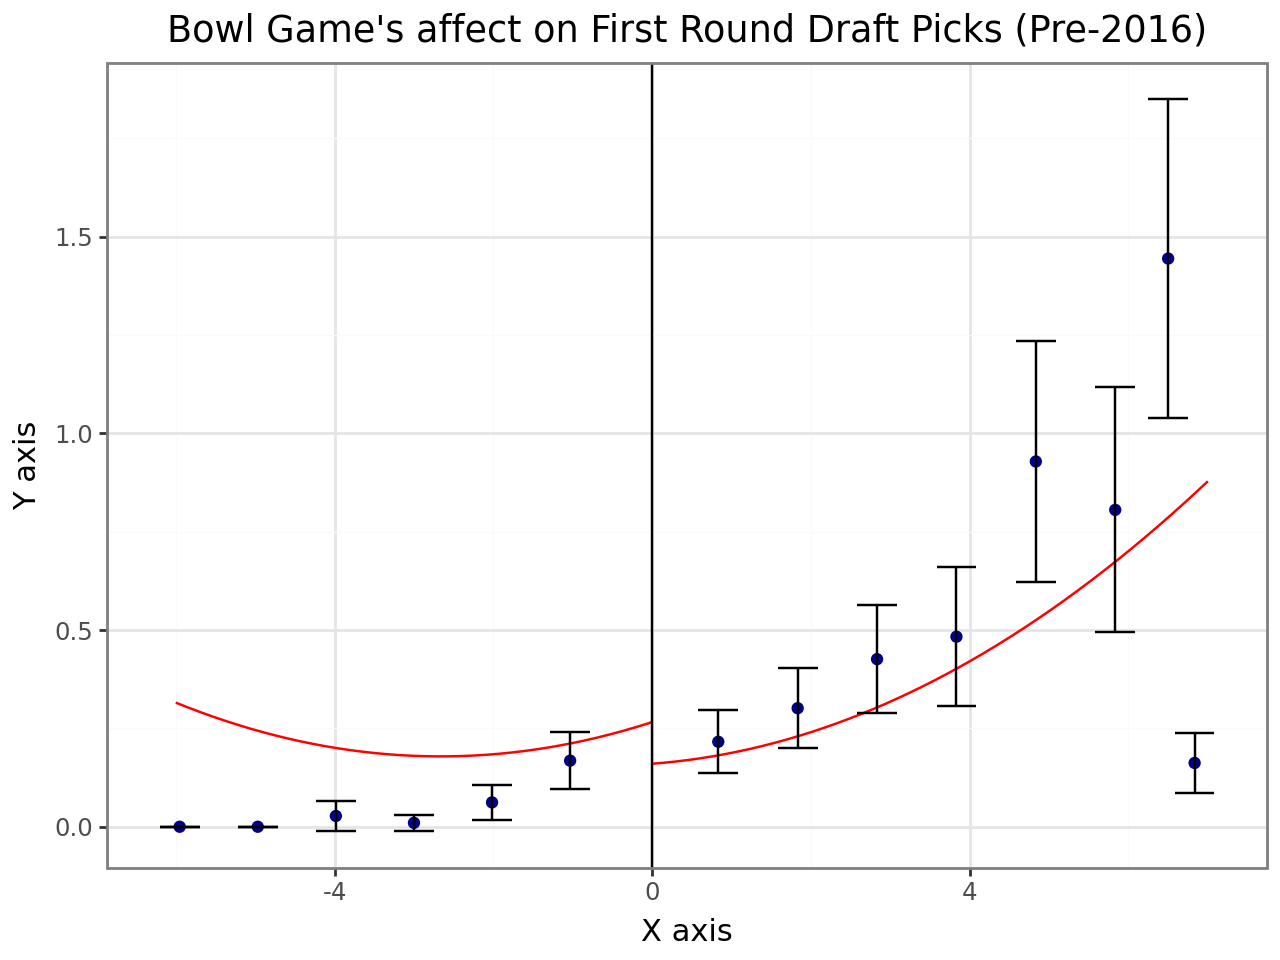

/home/porter/Desktop/cfb-projects/.venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
/home/porter/Desktop/cfb-projects/.venv/lib/python3.14/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide


Call: rdplot
Number of Observations:                  1217
Kernel:                               Uniform
Polynomial Order Est. (p):                  2

                                Left      Right
------------------------------------------------
Number of Observations           456        761
Number of Effective Obs          456        761
Bandwidth poly. fit (h)          6.0        7.0
Number of bins scale               1          1
Bins Selected                     61         21
Average Bin Length             0.233        nan
Median Bin Length              0.333        nan
IMSE-optimal bins               10.0        6.0
Mimicking Variance bins         61.0       21.0

Relative to IMSE-optimal:
Implied scale                    6.1        3.5
WIMSE variance weight          0.004      0.023
WIMSE bias weight              0.996      0.977

In [55]:
rdplot(y,x,covs=covariates,ci=95,title='Bowl Game\'s affect on First Round Draft Picks (Pre-2016)',p=2)